# **Fourier Spectrum Plot**

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [5]:
img = cv2.imread('/kaggle/input/datasets/abhashkharel7/imageippr/flower.jpg',cv2.IMREAD_GRAYSCALE)
img

array([[ 15,  15,  15, ...,  90, 100, 106],
       [ 15,  15,  15, ...,  90, 100, 106],
       [ 14,  15,  15, ...,  90, 100, 106],
       ...,
       [ 18,  19,  19, ...,   0,   0,   0],
       [ 18,  19,  19, ...,   0,   0,   0],
       [ 18,  20,  20, ...,   0,   0,   0]], dtype=uint8)

In [6]:
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
mag_spc = 20 * np.log(np.abs(fshift)+1)

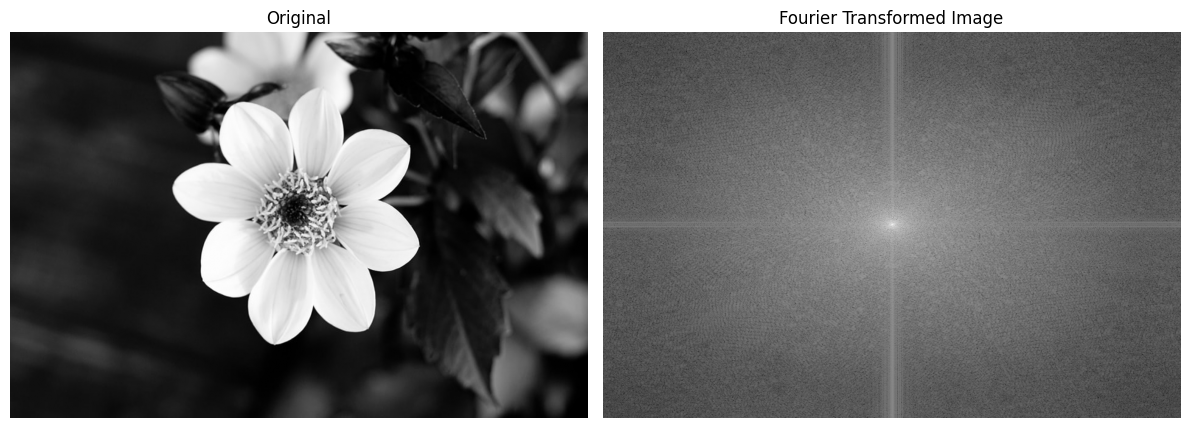

In [7]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(mag_spc, cmap='gray')
plt.title('Fourier Transformed Image')
plt.axis('off')
plt.tight_layout()
plt.show()

# **Ideal Lowpass Filter**

In [13]:
def ideal_lowpass(shape, cutoff):
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2

    H = np.zeros((rows, cols), dtype=np.float32)

    for u in range(rows):
        for v in range(cols):
            D = np.sqrt((u - crow) ** 2 + (v - ccol) ** 2)
            if D <= cutoff:
                H[u, v] = 1

    return H

In [20]:
dft = cv2.dft(np.float32(img), flags = cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

cutoff = 50 

H = ideal_lowpass(img.shape,cutoff)

H3ch = H[:,:,np.newaxis]

filtered = dft_shift * H3ch

f_ishift = np.fft.ifftshift(filtered)
imgb = cv2.idft(f_ishift)
imgb = cv2.magnitude(imgb[:,:,0],imgb[:,:,1])
imgb = cv2.normalize(imgb, None , 0 , 255 , cv2.NORM_MINMAX)
imgb = np.uint8(imgb)

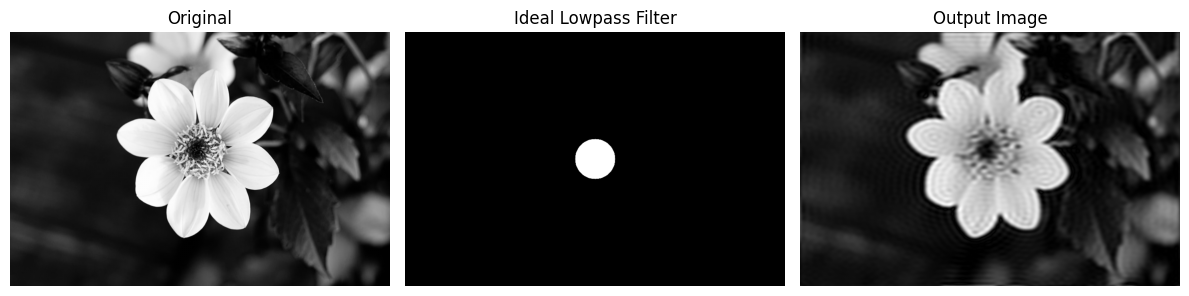

In [23]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(H, cmap='gray')
plt.title('Ideal Lowpass Filter')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(imgb, cmap='gray')
plt.title('Output Image')
plt.axis('off')
plt.tight_layout()
plt.show()

# **Gaussian Lowpass Filter**

In [27]:
def gaussian_lowpass(shape, cutoff):
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2

    H = np.zeros((rows, cols), dtype=np.float32)

    for u in range(rows):
        for v in range(cols):
            D = np.sqrt((u - crow) ** 2 + (v - ccol) ** 2)
            H[u, v] = np.exp(-(D**2)/(2*(cutoff**2)))

    return H

In [32]:
dft = cv2.dft(np.float32(img), flags = cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

cutoff = 50 

H = gaussian_lowpass(img.shape,cutoff)

H3ch = H[:,:,np.newaxis]

filtered = dft_shift * H3ch

f_ishift = np.fft.ifftshift(filtered)
imgb = cv2.idft(f_ishift)
imgb = cv2.magnitude(imgb[:,:,0],imgb[:,:,1])
imgb = cv2.normalize(imgb, None , 0 , 255 , cv2.NORM_MINMAX)
imgb = np.uint8(imgb)

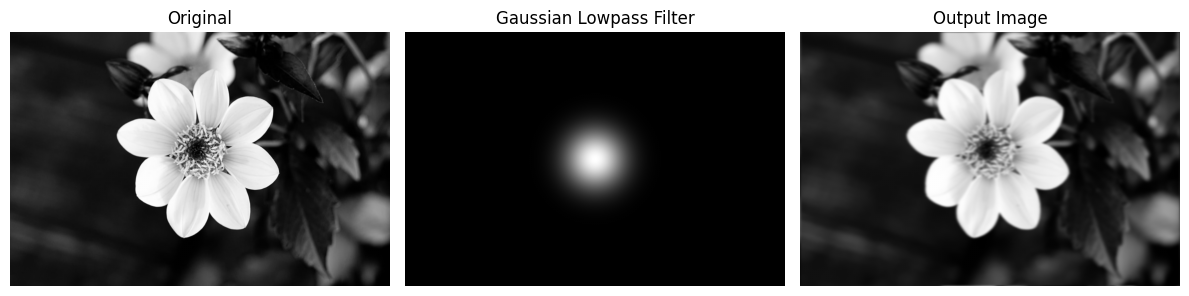

In [33]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(H, cmap='gray')
plt.title('Gaussian Lowpass Filter')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(imgb, cmap='gray')
plt.title('Output Image')
plt.axis('off')
plt.tight_layout()
plt.show()

# **Butterworth Lowpass Filter**

In [30]:
def butterworth_lowpass(shape, cutoff , order):
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2

    H = np.zeros((rows, cols), dtype=np.float32)

    for u in range(rows):
        for v in range(cols):
            D = np.sqrt((u - crow) ** 2 + (v - ccol) ** 2)
            H[u, v] = 1/(1+(D/cutoff)**(2*order))
    return H

In [34]:
dft = cv2.dft(np.float32(img), flags = cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

cutoff = 50 
order = 2

H = butterworth_lowpass(img.shape,cutoff,order)

H3ch = H[:,:,np.newaxis]

filtered = dft_shift * H3ch

f_ishift = np.fft.ifftshift(filtered)
imgb = cv2.idft(f_ishift)
imgb = cv2.magnitude(imgb[:,:,0],imgb[:,:,1])
imgb = cv2.normalize(imgb, None , 0 , 255 , cv2.NORM_MINMAX)
imgb = np.uint8(imgb)

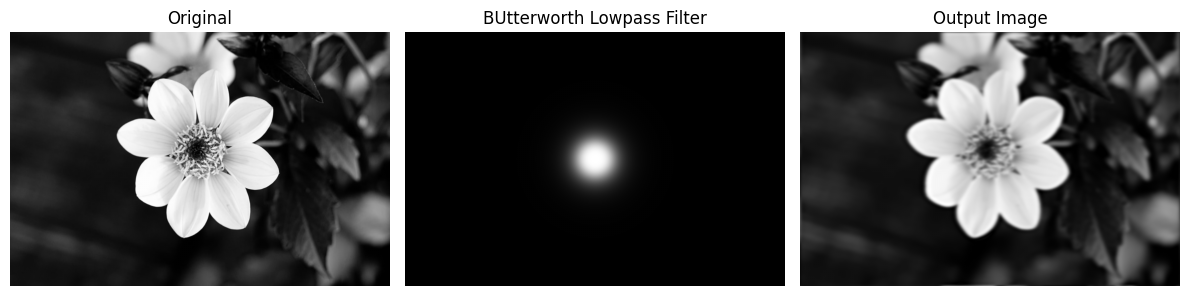

In [35]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(H, cmap='gray')
plt.title('BUtterworth Lowpass Filter')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(imgb, cmap='gray')
plt.title('Output Image')
plt.axis('off')
plt.tight_layout()
plt.show()